# Zscore Plot

### Comparison with Simplified `UW_DRP_2026S_pairs_trading_project.ipynb`

While the simplified notebook (`UW_DRP_2026S_pairs_trading_project.ipynb`) retains only the core pipeline for calculating Z-scores and outputting the computed data table, this notebook (`Pairs Statistics - zscoregraph.ipynb`) is a comprehensive version that includes additional analysis and visualization logic.

Compared to the simplified version, this notebook includes **5 redundant/optional functions** and **2 redundant plotting functions**:

1. **`compute_returns(prices)`**
   * **Purpose**: Calculates daily simple returns (percentage changes) for each stock.
   * **Why Redundant**: The OLS regression for the hedge ratio and spread calculation uses absolute prices rather than returns.

2. **`compute_pair_correlations(daily_returns, pairs)`**
   * **Purpose**: Computes the Pearson return correlation coefficient for each pair.
   * **Why Redundant**: Used only as a preliminary filtering metric during initial pair selection and does not participate in Z-score calculation.

3. **`build_pair_summary_table(prices, daily_returns, pairs)`**
   * **Purpose**: Summarizes each pair's date range, valid overlapping days, and return correlation into a table.
   * **Why Redundant**: Used only for qualitative display during the initial selection phase.

4. **`label_pair_candidate(cointegration_results)`**
   * **Purpose**: Categorizes each pair as a `strong`, `weak`, or `poor` trading candidate based on Engle-Granger cointegration test p-values.
   * **Why Redundant**: Used only for qualitative filtering; the backtester and Z-score calculations do not consume this label.

5. **`zscore_to_signal(zscore, entry_threshold, exit_threshold)`**
   * **Purpose**: Converts continuous Z-scores into discrete trading signals (1, -1, 0).
   * **Why Redundant**: Needed only for strategy backtesting (Section 2) and is not required for the Z-score calculation pipeline itself.

6. **`plot_spread(pairs_table)`**
   * **Purpose**: Plots the spread series and its mean line for each pair over time.
   * **Why Redundant**: Purely a visualization utility.

7. **`plot_zscore(pairs_table)`**
   * **Purpose**: Plots the Z-score series and +/-1.0 entry threshold lines for each pair over time.
   * **Why Redundant**: Purely a visualization utility.

Pipeline: `download_adjusted_close` → `clean_price_data` → `compute_returns` / `compute_pair_correlations` → `build_pair_summary_table` → `test_cointegration` → `label_pair_candidate` → `compute_hedge_ratio` → `compute_spread` → `compute_zscore` → `build_pairs_table` → `plot_spread` / `plot_zscore`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations

In [2]:
def download_adjusted_close(tickers, start, end):
    """Purpose: Download adjusted closing prices for tickers using yfinance."""
    if isinstance(tickers, str):
        tickers = [tickers]
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)
    prices = raw["Close"]
    if isinstance(prices, pd.Series):
        prices = prices.to_frame(name=tickers[0])
    return prices

In [3]:
def clean_price_data(prices):
    """Purpose: Clean missing values by forward-filling and trimming to a common start date."""
    cleaned = prices.dropna(axis=1, how="all")
    cleaned = cleaned.ffill()
    common_start = max(cleaned[col].first_valid_index() for col in cleaned.columns)
    cleaned = cleaned.loc[common_start:]
    assert cleaned.isna().sum().sum() == 0
    return cleaned

In [4]:
def compute_returns(prices):
    """Purpose: Compute daily simple returns using pct_change."""
    daily_returns = prices.pct_change().dropna(how="all")
    assert not daily_returns.isna().any().any()
    return daily_returns

In [5]:
def compute_pair_correlations(daily_returns, pairs):
    """Purpose: Compute Pearson return correlation for each pair."""
    correlations = {}
    for asset_1, asset_2 in pairs:
        correlations[(asset_1, asset_2)] = daily_returns[asset_1].corr(daily_returns[asset_2])
    assert all(-1 <= v <= 1 for v in correlations.values())
    return correlations

In [6]:
def build_pair_summary_table(prices, daily_returns, pairs):
    """Purpose: Summarize each pair's date range, number of active days, and return correlation."""
    correlations = compute_pair_correlations(daily_returns, pairs)
    rows = []
    for asset_1, asset_2 in pairs:
        pair_prices = prices[[asset_1, asset_2]].dropna()
        rows.append({
            "pair": f"{asset_1}-{asset_2}",
            "asset_1": asset_1,
            "asset_2": asset_2,
            "start_date": pair_prices.index.min(),
            "end_date": pair_prices.index.max(),
            "n_days": len(pair_prices),
            "return_correlation": correlations[(asset_1, asset_2)],
        })
    pair_summary_table = pd.DataFrame(rows)
    expected_columns = {"pair", "asset_1", "asset_2", "start_date", "end_date", "n_days", "return_correlation"}
    assert set(pair_summary_table.columns) == expected_columns
    return pair_summary_table

In [7]:
def test_cointegration(prices, pair):
    """Purpose: Test cointegration between two assets using Engle-Granger two-step test."""
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    _, p_value, _ = coint(s1, s2)
    return {
        "pair": f"{asset_1}-{asset_2}",
        "p_value": round(p_value, 4),
        "is_cointegrated": p_value < 0.05,
    }

In [8]:
def label_pair_candidate(cointegration_results):
    """Purpose: Label each pair candidate as strong, weak, or poor based on cointegration p-value."""
    def _label(p):
        if p < 0.05:
            return "strong"
        elif p < 0.10:
            return "weak"
        else:
            return "poor"

    result = cointegration_results.copy()
    result["candidate"] = result["p_value"].apply(_label)
    return result

In [9]:
def compute_hedge_ratio(prices, pair):
    """Purpose: Estimate the hedge ratio (beta) and intercept (alpha) using OLS regression."""
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    model = sm.OLS(s1, sm.add_constant(s2)).fit()
    alpha = float(model.params["const"])
    beta  = float(model.params[asset_2])
    return alpha, beta

In [10]:
def compute_spread(prices, pair, alpha, beta):
    """Purpose: Compute the spread (residual) between two assets as epsilon = P1 - (alpha + beta * P2)."""
    asset_1, asset_2 = pair
    spread = prices[asset_1] - (alpha + beta * prices[asset_2])
    spread.name = f"{asset_1}-{asset_2}_spread"
    return spread.dropna()

In [11]:
def compute_zscore(spread, window=None):
    """Purpose: Compute static (full history) or rolling z-score of the spread."""
    if window is None:
        zscore = (spread - spread.mean()) / spread.std()
    else:
        rolling_mean = spread.rolling(window).mean()
        rolling_std  = spread.rolling(window).std()
        zscore = (spread - rolling_mean) / rolling_std
    return zscore.dropna()

In [12]:
def build_pairs_table(prices, pairs, window=None):
    """Purpose: Run full pairs analysis pipeline and stack results into a single long DataFrame."""
    frames = []
    for pair in pairs:
        asset_1, asset_2 = pair
        alpha, beta = compute_hedge_ratio(prices, pair)
        spread      = compute_spread(prices, pair, alpha, beta)
        zscore      = compute_zscore(spread, window)

        frames.append(pd.DataFrame({
            "date":    spread.index,
            "pair":    f"{asset_1}-{asset_2}",
            "asset_1": asset_1,
            "asset_2": asset_2,
            "alpha":   alpha,
            "beta":    beta,
            "spread":  spread.values,
            "z_score": zscore.reindex(spread.index).values,
        }))

    pairs_table = pd.concat(frames, ignore_index=True)
    assert set(pairs_table.columns) == {"date", "pair", "asset_1", "asset_2", "alpha", "beta", "spread", "z_score"}
    return pairs_table

In [13]:
def plot_spread(pairs_table):
    """Purpose: Plot spread series and its mean line for each pair over time."""
    pair_names = pairs_table["pair"].unique()
    n = len(pair_names)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, pair_name in zip(axes, pair_names):
        subset = pairs_table[pairs_table["pair"] == pair_name].sort_values("date")
        mean_val = subset["spread"].mean()
        ax.plot(subset["date"], subset["spread"], linewidth=1.2, label="Spread")
        ax.axhline(mean_val, color="red", linestyle="--", linewidth=1, label=f"Mean ({mean_val:.2f})")
        ax.set_title(f"{pair_name} — Spread over Time")
        ax.set_ylabel("Spread (epsilon)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

In [14]:
def plot_zscore(pairs_table):
    """Purpose: Plot the z-score over time for each pair with +/-1 threshold lines."""
    pair_names = pairs_table["pair"].unique()
    n = len(pair_names)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, pair_name in zip(axes, pair_names):
        subset = pairs_table[pairs_table["pair"] == pair_name].sort_values("date")
        ax.plot(subset["date"], subset["z_score"], linewidth=1.2, color="steelblue", label="Z-score")
        ax.axhline( 1.0, color="red",   linestyle="--", linewidth=1, label="+1 threshold")
        ax.axhline(-1.0, color="green", linestyle="--", linewidth=1, label="-1 threshold")
        ax.axhline( 0.0, color="black", linestyle=":",  linewidth=0.8)
        ax.set_title(f"{pair_name} — Z-score over Time")
        ax.set_ylabel("Z-score")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


[                       0%                       ]


[**********            20%                       ]  2 of 10 completed
[**********            20%                       ]  2 of 10 completed


[**********            20%                       ]  2 of 10 completed
[**********            20%                       ]  2 of 10 completed


[**********************60%****                   ]  6 of 10 completed
[**********************60%****                   ]  6 of 10 completed
[**********************60%****                   ]  6 of 10 completed


[**********************90%******************     ]  9 of 10 completed
[*********************100%***********************]  10 of 10 completed

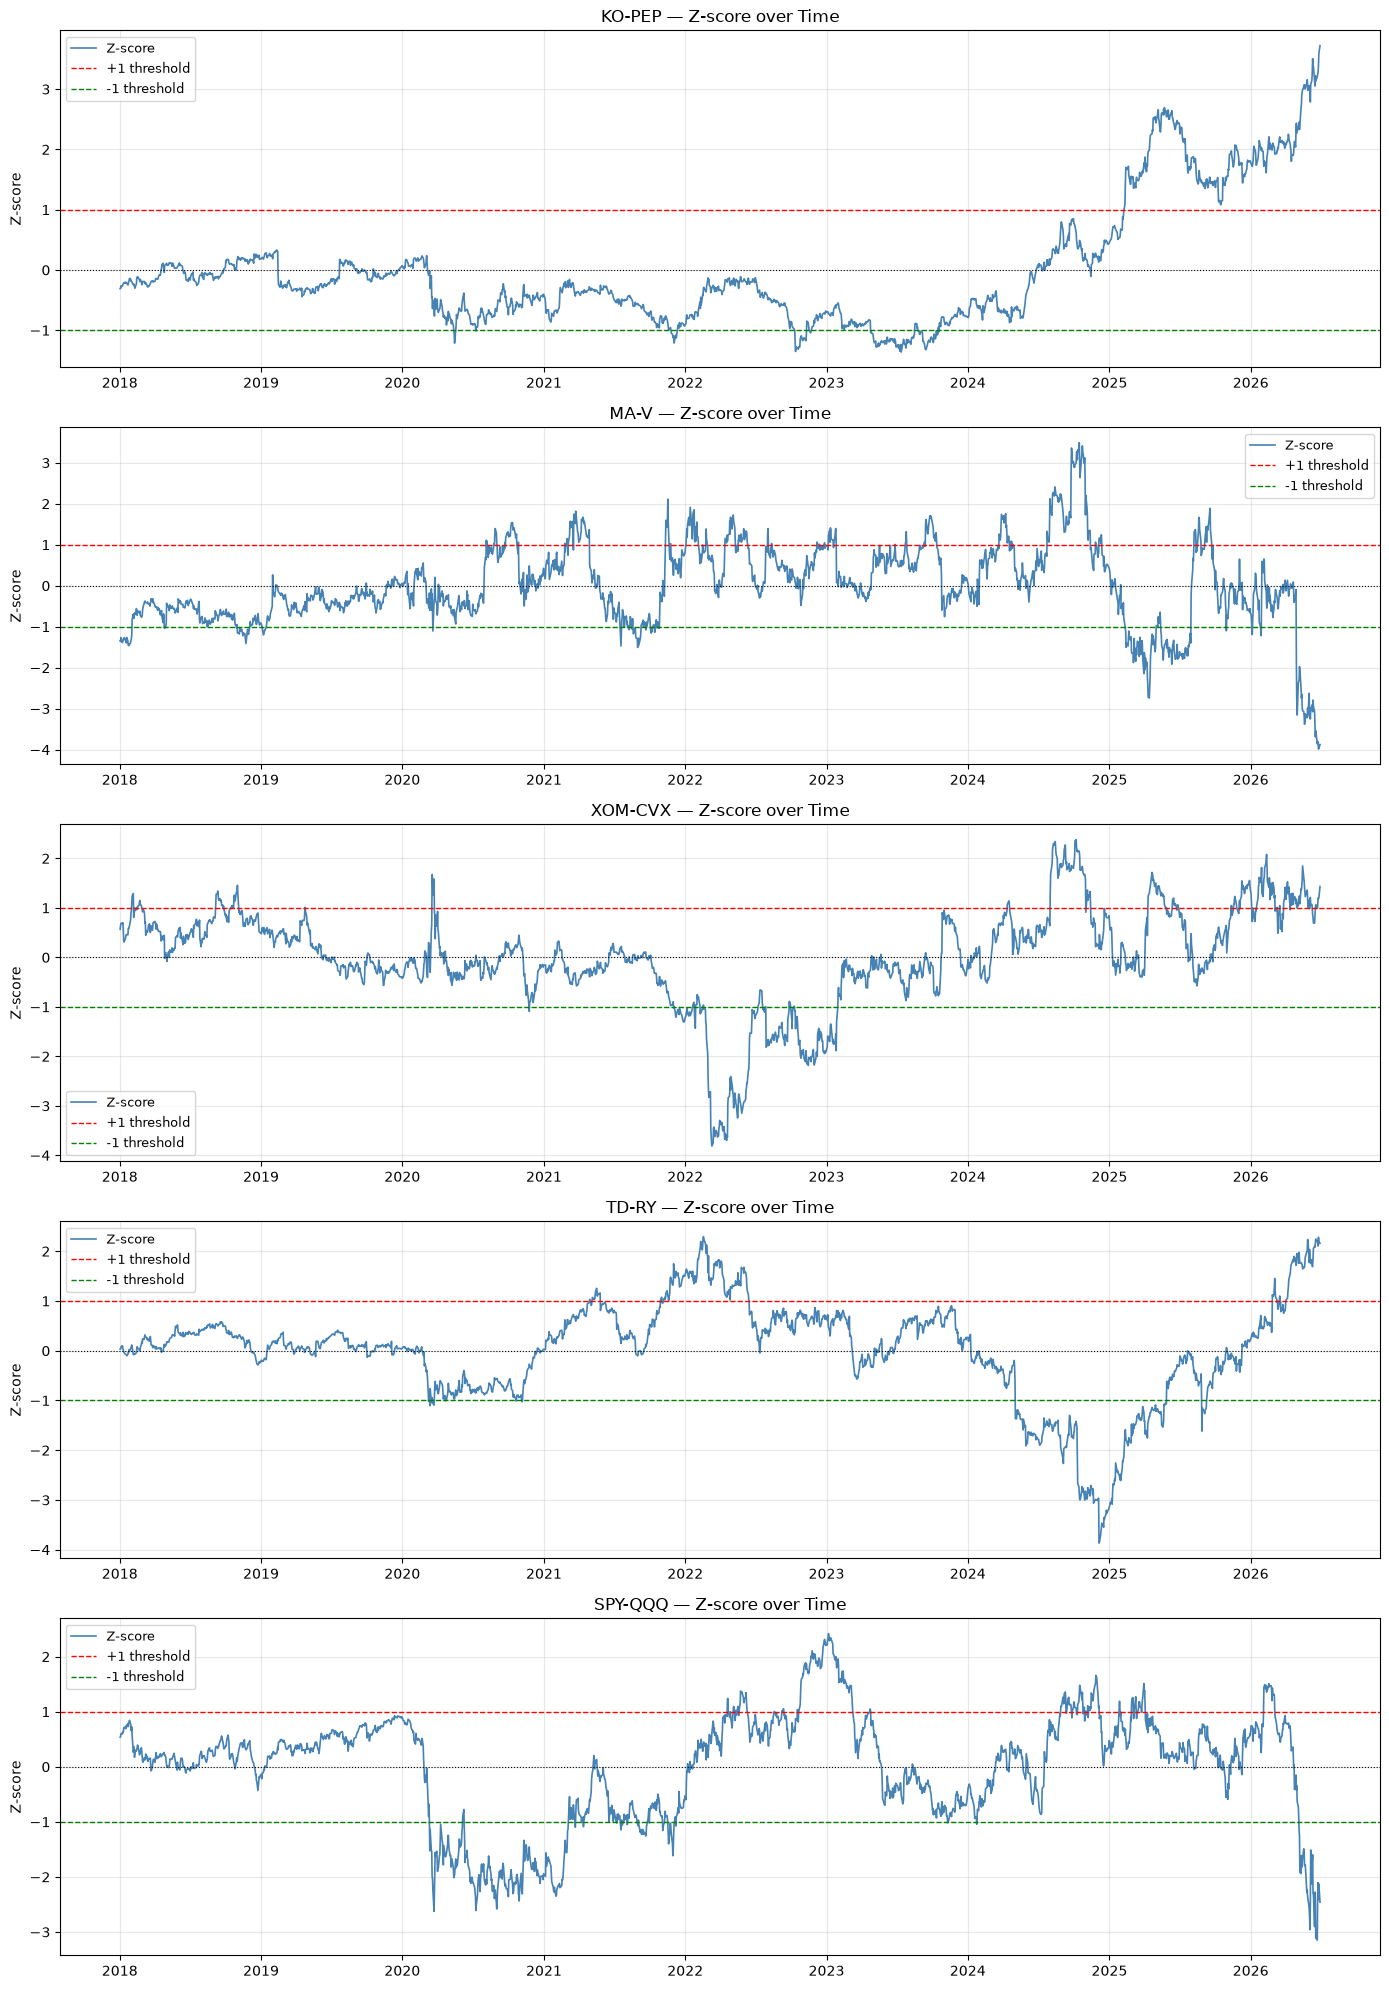

,date,pair,asset_1,asset_2,alpha,beta,spread,z_score
0,2018-01-02,KO-PEP,KO,PEP,4.737055,0.359794,-2.327808,-0.309233
1,2018-01-03,KO-PEP,KO,PEP,4.737055,0.359794,-2.319079,-0.308073
2,2018-01-04,KO-PEP,KO,PEP,4.737055,0.359794,-1.987094,-0.263971
3,2018-01-05,KO-PEP,KO,PEP,4.737055,0.359794,-2.088715,-0.277471
4,2018-01-08,KO-PEP,KO,PEP,4.737055,0.359794,-1.954677,-0.259665
...,...,...,...,...,...,...,...,...
10660,2026-06-23,SPY-QQQ,SPY,QQQ,85.029035,0.954548,-32.662536,-2.281632
10661,2026-06-24,SPY-QQQ,SPY,QQQ,85.029035,0.954548,-30.110253,-2.103343
10662,2026-06-25,SPY-QQQ,SPY,QQQ,85.029035,0.954548,-34.548464,-2.413373
10663,2026-06-26,SPY-QQQ,SPY,QQQ,85.029035,0.954548,-30.446628,-2.126841


In [ ]:

DEFAULT_PAIRS = [("KO", "PEP"), ("MA", "V"), ("XOM", "CVX"), ("TD", "RY"), ("SPY", "QQQ")]
ALL_TICKERS = sorted({ticker for pair in DEFAULT_PAIRS for ticker in pair})


prices = download_adjusted_close(ALL_TICKERS, "2018-01-01", "2026-06-30")
cleaned_prices = clean_price_data(prices)
pairs_table = build_pairs_table(cleaned_prices, DEFAULT_PAIRS)


fig = plot_zscore(pairs_table)
plt.show()


pairs_table